# Unit 9 Artefact 2: Business Impact Analysis and Recovery Objectives for Pampered Pets

Ian Stevens, Security and Risk Management, Unit 9.

My executive summary stated that Pampered Pets needed 24/7/365 availability with an RTO and an RPO of under one minute, and concluded that only an active-active, multi-region cloud architecture could achieve this (Stevens, 2026). It did not show where those objectives came from. This notebook does what should have come first: a business impact analysis (BIA) that sets the maximum tolerable period of disruption (MTPD), RTO and RPO for each business function, followed by a cost comparison of recovery strategies for the one function where the choice of technology matters, the online shop and its order data.

It follows the BIA steps that Lyon (2022) takes from ISO 31010: find the critical processes, estimate the consequences of disruption over a defined time, identify dependencies and workarounds, set a maximum acceptable outage (MAO) for each process, and then set RTOs for the technology it relies on. NIST SP 800-34 Rev. 1 (Swanson et al., 2010) follows the same order and calls the MAO the maximum tolerable downtime. Neither Lyon (2022) nor Hollcroft and Lyon's (2022) chapter on business continuity plans mentions an RPO, so the RPO column follows NIST. The recovery tiers are those in AWS's disaster recovery whitepaper (AWS, 2021), and the cost comparison borrows the logic of Andrade et al. (2017) while applying the corrections from Artefact 1.

**Every figure below is an assumption made for this exercise.** The case study gives no turnover, order volumes or IT costs. The aim is to show which decisions survive the uncertainty, not to produce a budget.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
pd.set_option("display.width", 160); pd.set_option("display.max_colwidth", 60)
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#0b0b0b",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e4e3df", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "lines.linewidth": 2,
})
BLUE, ORANGE, AQUA, VIOLET, INK, RED = "#2a78d6", "#eb6834", "#1baf7a", "#7c5cd6", "#52514e", "#c23b3b"
tri = lambda a, m, b, n=None: rng.triangular(a, m, b, n)

## 1. Business functions and dependencies

The functions come from the assignment brief as summarised in our team report (90% of sales in store, data held on two local computers with no backup policy, PCs in the warehouse and at the front desk, staff phones on the shop Wi-Fi) and from the digitalised design in the team report and my executive summary (an online shop, an online orders database, an ERP and international suppliers) (Group 2, 2025; Stevens, 2026).

In [2]:
functions = pd.DataFrame([
    ("F1", "In-store sales",            "Card terminal, till PC, broadband", "Manual sales log; card terminal on its own mobile data"),
    ("F2", "Online shop and ordering",  "Hosted e-commerce platform, payment provider", "Holding page; take phone orders"),
    ("F3", "Customer and order data",   "Online orders database, ERP", "Restore from backup; re-key from payment provider records"),
    ("F4", "Supplier ordering and stock", "ERP, email, warehouse PC", "Order by phone from last known stock count"),
    ("F5", "Accounts, VAT and payroll", "Two local PCs (status quo), later cloud accounting", "Restore from backup; rebuild from bank statements"),
    ("F6", "Email",                     "Hosted email", "Phone; webmail from another device"),
], columns=["id", "function", "depends on", "manual or alternative workaround"]).set_index("id")
print(functions.to_string())

                       function                                          depends on                           manual or alternative workaround
id                                                                                                                                            
F1               In-store sales                   Card terminal, till PC, broadband     Manual sales log; card terminal on its own mobile data
F2     Online shop and ordering        Hosted e-commerce platform, payment provider                            Holding page; take phone orders
F3      Customer and order data                         Online orders database, ERP  Restore from backup; re-key from payment provider records
F4  Supplier ordering and stock                            ERP, email, warehouse PC                 Order by phone from last known stock count
F5    Accounts, VAT and payroll  Two local PCs (status quo), later cloud accounting          Restore from backup; rebuild from bank statements

## 2. Impact over time and the MTPD

Each function is scored for impact at five points after disruption starts, on a 1 to 5 scale (1 negligible, 3 serious, 4 severe, 5 threatens the business). Hollcroft and Lyon (2022) suggest anchoring such a scale by asking the people who hold the money two questions: what loss could be paid without anyone's approval, and what loss would threaten survival. For a business run by its owner those are the owner's answers, which I do not have, so the scores below are my own judgement. The scores combine lost sales, regulatory exposure (UK GDPR breach reporting within 72 hours, VAT deadlines), harm to supplier relationships and harm to reputation with the high-profile customers in the brief. The MTPD is the first point at which the impact reaches 4. I set the RTO at no more than half the MTPD, leaving time to detect the problem and decide to invoke the plan, and the RPO from how much data each function creates and whether it can be rebuilt from elsewhere.

In [3]:
HORIZONS = ["1 h", "4 h", "24 h", "72 h", "1 week"]
HOURS = np.array([1, 4, 24, 72, 168])
impact = pd.DataFrame({
    "F1": [2, 3, 4, 5, 5],   # 75-90% of revenue; manual fallback buys time
    "F2": [1, 2, 3, 4, 4],   # 10-50% of revenue after digitalisation; customers can wait or phone
    "F3": [1, 2, 3, 4, 5],   # orders cannot be fulfilled; personal data breach clock if lost or exposed
    "F4": [1, 1, 2, 3, 4],   # stock buffer of days; overseas lead times are long anyway
    "F5": [1, 1, 1, 2, 3],   # deadlines are monthly or quarterly
    "F6": [1, 2, 3, 3, 4],   # supplier and customer contact; phone is a workaround
}, index=HORIZONS).T
rpo = {"F1": "End of previous day (card provider holds transactions)",
       "F2": "Not applicable (configuration rebuilt from backup)",
       "F3": "15 minutes",
       "F4": "24 hours",
       "F5": "24 hours",
       "F6": "Provider retention"}

def mtpd(row):
    hit = np.where(row.values >= 4)[0]
    return HOURS[hit[0]] if len(hit) else 336

bia = impact.copy()
bia["MTPD (h)"] = impact.apply(mtpd, axis=1)
bia["RTO (h)"] = (bia["MTPD (h)"] / 2).clip(upper=48)
bia["RPO"] = pd.Series(rpo)
bia.insert(0, "function", functions.function)
print(bia.to_string())

                       function  1 h  4 h  24 h  72 h  1 week  MTPD (h)  RTO (h)                                                     RPO
F1               In-store sales    2    3     4     5       5        24     12.0  End of previous day (card provider holds transactions)
F2     Online shop and ordering    1    2     3     4       4        72     36.0      Not applicable (configuration rebuilt from backup)
F3      Customer and order data    1    2     3     4       5        72     36.0                                              15 minutes
F4  Supplier ordering and stock    1    1     2     3       4       168     48.0                                                24 hours
F5    Accounts, VAT and payroll    1    1     1     2       3       336     48.0                                                24 hours
F6                        Email    1    2     3     3       4       168     48.0                                      Provider retention


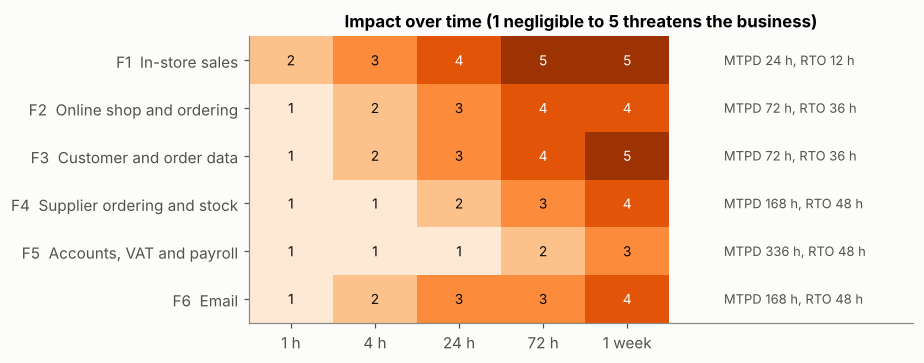

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 3.4))
im = ax.imshow(impact.values, cmap="Oranges", vmin=0.5, vmax=5.5, aspect="auto")
for (i, j), v in np.ndenumerate(impact.values):
    ax.text(j, i, v, ha="center", va="center", color="white" if v >= 4 else "#0b0b0b", fontsize=9)
ax.set_xticks(range(5), HORIZONS); ax.set_yticks(range(6), [f"{k}  {functions.function[k]}" for k in impact.index])
ax.grid(False)
for i, k in enumerate(impact.index):
    ax.text(5.15, i, f"MTPD {bia.loc[k, 'MTPD (h)']:g} h, RTO {bia.loc[k, 'RTO (h)']:g} h", va="center", fontsize=8.5, color=INK)
ax.set_xlim(-0.5, 7.4)
ax.set_title("Impact over time (1 negligible to 5 threatens the business)")
fig.tight_layout()
fig.savefig("figures/u9_bia_heatmap.png", dpi=160, bbox_inches="tight")

None of the six functions comes close to needing an RTO of one minute. The tightest, in-store sales, has an MTPD of a day and is protected by a manual workaround and a card terminal that does not depend on the shop's network, not by a data centre. The tightest RPO belongs to the order data (F3), because orders and personal data are created continuously and a lost order is a customer who has paid and receives nothing. That points to protecting data more than to faster failover.

## 3. Recovery strategies for the online shop and order data

The four tiers follow AWS (2021): backup and restore, pilot light, warm standby and multi-site active/active. A fifth option, the status quo of no deliberate recovery arrangements, is included as a baseline. Two kinds of event are modelled separately because they behave differently:

* **Infrastructure disasters** (loss of a hosting region or the platform for hours, like the AWS us-east-1 disruption of 19 to 20 October 2025 (AWS, 2025)). Replication and failover help.
* **Data disasters** (ransomware, malicious or accidental deletion, corruption). Replication copies the damage, so recovery depends on point-in-time backups. AWS (2021) itself says that for data corruption or deletion an active/active design 'will always' have a recovery time above zero and a recovery point before the problem was discovered.

Recovery times and costs are ranges (minimum, most likely, maximum). Costs are annual and include running the standby and a share of set-up and testing.

In [5]:
tiers = pd.DataFrame([
    # name, RTO infra (h) tri, RPO infra (h) tri, RPO data-disaster (h) tri, restore time data-disaster (h) tri, annual cost (GBP) tri
    ("No arrangements",       (24, 72, 240), (24, 168, 720), (24, 168, 720), (48, 120, 336), (0, 0, 0)),
    ("Backup and restore",    (4, 12, 24),   (0.25, 1, 4),   (1, 4, 24),     (4, 12, 24),    (300, 700, 1500)),
    ("Pilot light",           (0.5, 1, 3),   (0.02, 0.1, 0.25), (1, 4, 24),  (4, 12, 24),    (1500, 3000, 6000)),
    ("Warm standby",          (0.1, 0.25, 0.5), (0.005, 0.02, 0.1), (1, 4, 24), (4, 12, 24), (4000, 8000, 15000)),
    ("Active/active",         (0.0, 0.01, 0.02), (0.0, 0.005, 0.02), (1, 4, 24), (4, 12, 24), (15000, 30000, 60000)),
], columns=["tier", "rto", "rpo", "rpo_data", "rto_data", "cost"]).set_index("tier")
print(tiers.to_string())

                                  rto                 rpo        rpo_data        rto_data                   cost
tier                                                                                                            
No arrangements         (24, 72, 240)      (24, 168, 720)  (24, 168, 720)  (48, 120, 336)              (0, 0, 0)
Backup and restore        (4, 12, 24)        (0.25, 1, 4)      (1, 4, 24)     (4, 12, 24)       (300, 700, 1500)
Pilot light               (0.5, 1, 3)   (0.02, 0.1, 0.25)      (1, 4, 24)     (4, 12, 24)     (1500, 3000, 6000)
Warm standby         (0.1, 0.25, 0.5)  (0.005, 0.02, 0.1)      (1, 4, 24)     (4, 12, 24)    (4000, 8000, 15000)
Active/active       (0.0, 0.01, 0.02)  (0.0, 0.005, 0.02)      (1, 4, 24)     (4, 12, 24)  (15000, 30000, 60000)


The business inputs are the most uncertain. Turnover is assumed to be between £250,000 and £900,000, with between 10% and 50% of sales online after digitalisation (the team report's upper figure was growth of up to 50%). Only part of the sales during an outage is lost, because many customers come back later or phone. Every hour is costed at the full value of lost sales, not the margin, which favours spending on recovery.

In [6]:
N = 20_000
business = dict(
    turnover=tri(250_000, 450_000, 900_000, N),
    online_share=tri(0.10, 0.25, 0.50, N),
    lost_fraction=tri(0.2, 0.5, 0.9, N),          # share of online sales during an outage that never return
    peak_factor=tri(1.0, 1.5, 3.0, N),            # outages tend to be noticed in busy hours
    infra_rate=tri(0.05, 0.25, 1.0, N),           # infrastructure disasters per year affecting the shop
    data_rate=tri(0.01, 0.05, 0.20, N),           # data disasters per year (ransomware, deletion, corruption)
    order_value=tri(25, 40, 70, N),
    cost_per_lost_order=tri(10, 30, 80, N),       # refund handling, goodwill, re-keying, on top of the sale
    breach_cost=tri(0, 2_000, 15_000, N),         # extra handling if customer data is lost (UK GDPR notification, advice)
)
b = pd.DataFrame(business)
b["cost_per_hour"] = b.turnover * b.online_share / 8760 * b.lost_fraction * b.peak_factor
b["orders_per_hour"] = b.turnover * b.online_share / b.order_value / 8760
print(b.describe(percentiles=[0.05, 0.5, 0.95]).T[["5%", "50%", "95%"]].round(2).to_string())

                            5%        50%        95%
turnover             333105.70  517922.25  780063.21
online_share              0.15       0.27       0.43
lost_fraction             0.30       0.53       0.78
peak_factor               1.22       1.77       2.61
infra_rate                0.15       0.40       0.81
data_rate                 0.03       0.08       0.16
order_value              30.76      43.88      61.65
cost_per_lost_order      18.27      38.29      66.56
breach_cost            1228.27    5063.47   11848.81
cost_per_hour             5.78      14.74      34.77
orders_per_hour           0.17       0.37       0.74


For each input set and each tier the expected annual cost is the tier's own cost, plus the expected cost of downtime and lost orders from infrastructure disasters, plus the same from data disasters. All five tiers use the same random numbers, so the comparison between them is not affected by sampling noise (Eckstein and Riedmueller, 2002).

In [7]:
U = {k: rng.random(N) for k in ["rto", "rpo", "rpo_data", "rto_data", "cost"]}   # common random numbers

def tri_q(u, a, m, c):
    # inverse CDF of the triangular distribution, so every tier uses the same uniform draws
    if c == a:
        return np.full_like(u, a)
    f = (m - a) / (c - a)
    return np.where(u < f, a + np.sqrt(u * (c - a) * (m - a)), c - np.sqrt((1 - u) * (c - a) * (c - m)))

res = {}
for name, t in tiers.iterrows():
    rto, rpo = tri_q(U["rto"], *t.rto), tri_q(U["rpo"], *t.rpo)
    rpo_d, rto_d, cost = tri_q(U["rpo_data"], *t.rpo_data), tri_q(U["rto_data"], *t.rto_data), tri_q(U["cost"], *t.cost)
    infra = b.infra_rate * (rto * b.cost_per_hour + rpo * b.orders_per_hour * (b.order_value + b.cost_per_lost_order))
    data = b.data_rate * (rto_d * b.cost_per_hour + rpo_d * b.orders_per_hour * (b.order_value + b.cost_per_lost_order) + b.breach_cost)
    res[name] = pd.DataFrame({"tier_cost": cost, "infra_loss": infra, "data_loss": data, "total": cost + infra + data,
                              "downtime_h": b.infra_rate * rto + b.data_rate * rto_d})
summary = pd.DataFrame({n: {"tier cost (median)": r.tier_cost.median(),
                            "expected loss, infrastructure (median)": r.infra_loss.median(),
                            "expected loss, data disasters (median)": r.data_loss.median(),
                            "total (median)": r.total.median(),
                            "total (95th pct)": r.total.quantile(0.95),
                            "expected downtime h/yr (median)": r.downtime_h.median()} for n, r in res.items()}).T
totals = pd.DataFrame({n: r.total for n, r in res.items()})
summary["cheapest in % of input sets"] = totals.idxmin(axis=1).value_counts(normalize=True).reindex(summary.index).fillna(0) * 100
print(summary.round(0).to_string())

                    tier cost (median)  expected loss, infrastructure (median)  expected loss, data disasters (median)  total (median)  total (95th pct)  expected downtime h/yr (median)  cheapest in % of input sets
No arrangements                    0.0                                  3860.0                                  1333.0          5447.0           16007.0                             56.0                          1.0
Backup and restore               804.0                                    94.0                                   423.0          1415.0            2407.0                              6.0                         99.0
Pilot light                     3389.0                                     9.0                                   423.0          3956.0            5838.0                              2.0                          0.0
Warm standby                    8765.0                                     2.0                                   423.0          9324.0      

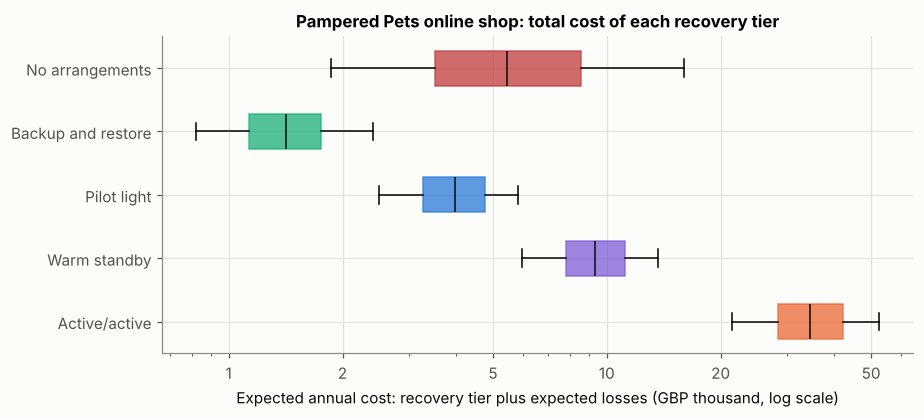

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 3.9))
order = list(tiers.index)
data = [totals[n] / 1000 for n in order]
bp = ax.boxplot(data, orientation="horizontal", whis=(5, 95), showfliers=False, patch_artist=True, widths=0.55,
                medianprops=dict(color="#0b0b0b"))
for patch, c in zip(bp["boxes"], [RED, AQUA, BLUE, VIOLET, ORANGE]):
    patch.set_facecolor(c); patch.set_alpha(0.75); patch.set_edgecolor(c)
ax.set_yticks(range(1, 6), order); ax.invert_yaxis()
ax.set_xscale("log"); ax.set_xticks([1, 2, 5, 10, 20, 50], ["1", "2", "5", "10", "20", "50"])
ax.set_xlabel("Expected annual cost: recovery tier plus expected losses (GBP thousand, log scale)")
ax.set_title("Pampered Pets online shop: total cost of each recovery tier")
fig.tight_layout()
fig.savefig("figures/u9_tiers.png", dpi=160, bbox_inches="tight")

## 4. What would justify the executive summary's objectives?

The break-even cost of downtime is the hourly loss at which a tier's extra annual cost is repaid by the downtime it avoids. Comparing each tier with backup and restore isolates the price of faster failover.

In [9]:
base = "Backup and restore"
rows = []
for n in ["Pilot light", "Warm standby", "Active/active"]:
    extra_cost = res[n].tier_cost - res[base].tier_cost
    hours_saved = res[base].downtime_h - res[n].downtime_h
    be = extra_cost / hours_saved
    rows.append(dict(tier=n, extra_cost_median=extra_cost.median(), hours_saved_median=hours_saved.median(),
                     breakeven_per_hour_median=be.median(), breakeven_5th=be.quantile(0.05),
                     modelled_cost_per_hour_95th=b.cost_per_hour.quantile(0.95),
                     pct_sets_worth_it=(be < b.cost_per_hour).mean() * 100))
be = pd.DataFrame(rows).set_index("tier")
print(be.round(1).to_string())
print(f"\nModelled cost of an hour of online downtime: median £{b.cost_per_hour.median():.0f}, 95th percentile £{b.cost_per_hour.quantile(0.95):.0f}")

               extra_cost_median  hours_saved_median  breakeven_per_hour_median  breakeven_5th  modelled_cost_per_hour_95th  pct_sets_worth_it
tier                                                                                                                                          
Pilot light               2585.6                 4.5                      579.5          213.4                         34.8                0.0
Warm standby              7961.4                 4.9                     1615.4          594.8                         34.8                0.0
Active/active            33090.1                 5.0                     6593.0         2391.8                         34.8                0.0

Modelled cost of an hour of online downtime: median £15, 95th percentile £35


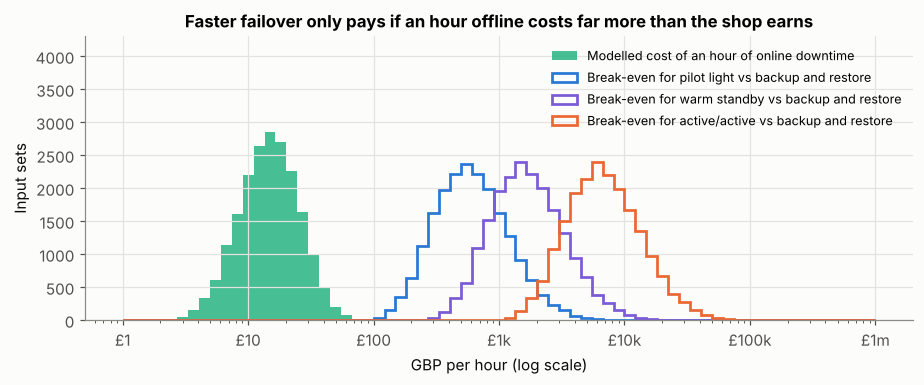

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 3.6))
bins = np.logspace(0, 6, 70)
ax.hist(b.cost_per_hour, bins=bins, color=AQUA, alpha=0.8, label="Modelled cost of an hour of online downtime")
for (n, r), c in zip(be.iterrows(), [BLUE, VIOLET, ORANGE]):
    vals = (res[n].tier_cost - res[base].tier_cost) / (res[base].downtime_h - res[n].downtime_h)
    ax.hist(vals, bins=bins, histtype="step", color=c, lw=1.8, label=f"Break-even for {n.lower()} vs backup and restore")
ax.set_xscale("log"); ax.set_xlabel("GBP per hour (log scale)"); ax.set_ylabel("Input sets")
ax.set_xticks([1, 10, 100, 1_000, 10_000, 100_000, 1_000_000], ["£1", "£10", "£100", "£1k", "£10k", "£100k", "£1m"])
ax.set_ylim(0, 4300)
ax.set_title("Faster failover only pays if an hour offline costs far more than the shop earns")
ax.legend(frameon=False, fontsize=8.3, loc="upper right")
fig.tight_layout()
fig.savefig("figures/u9_breakeven_pp.png", dpi=160, bbox_inches="tight")

## 5. Robustness and the status quo

The cost of downtime is the input I am least sure of, and the brief's high-profile customers suggest a reputational cost that lost sales do not capture. The comparison is therefore repeated with every hour of downtime costing up to 500 times the modelled figure.

In [11]:
# Robustness: what if an hour offline costs far more than lost sales, e.g. through reputational harm?
rows = []
for mult in [1, 10, 50, 100, 500]:
    tot = {n: r.total + (mult - 1) * b.cost_per_hour * r.downtime_h for n, r in res.items()}
    best = pd.DataFrame(tot).idxmin(axis=1).value_counts(normalize=True) * 100
    rows.append(best.rename(f"x{mult}"))
print("Cheapest tier (% of input sets) when every hour of downtime costs a multiple of the modelled figure:")
print(pd.DataFrame(rows).fillna(0).round(1).to_string())
diff = res["Active/active"].total - res[base].total
print(f"\nActive/active cheaper than backup and restore at the modelled cost: {(diff < 0).mean():.2%} of input sets")
need = (res["Active/active"].tier_cost - res[base].tier_cost) / ((res[base].downtime_h - res["Active/active"].downtime_h) * b.cost_per_hour)
print(f"Factor by which the cost of downtime would have to rise for active/active to break even: median {need.median():.0f}x, 5th percentile {need.quantile(0.05):.0f}x")

Cheapest tier (% of input sets) when every hour of downtime costs a multiple of the modelled figure:
      Backup and restore  No arrangements  Pilot light  Warm standby
x1                  98.9              1.1          0.0           0.0
x10                 95.1              0.0          4.9           0.0
x50                 40.1              0.0         59.9           0.0
x100                15.5              0.0         84.1           0.4
x500                 0.4              0.0         71.6          28.1

Active/active cheaper than backup and restore at the modelled cost: 0.00% of input sets
Factor by which the cost of downtime would have to rise for active/active to break even: median 461x, 5th percentile 116x


In [12]:
sq = res["No arrangements"]; br = res[base]
print(f"No arrangements: median expected annual loss £{sq.total.median():,.0f}, 95th percentile £{sq.total.quantile(0.95):,.0f}")
print(f"Backup and restore: median £{br.total.median():,.0f}, 95th percentile £{br.total.quantile(0.95):,.0f}")
print(f"Backup and restore cheaper than no arrangements in {(br.total < sq.total).mean():.1%} of input sets")
share_data = (br.data_loss / (br.infra_loss + br.data_loss)).median()
print(f"Share of backup-and-restore expected loss that comes from data disasters: {share_data:.0%}")

No arrangements: median expected annual loss £5,447, 95th percentile £16,007
Backup and restore: median £1,415, 95th percentile £2,407
Backup and restore cheaper than no arrangements in 98.9% of input sets
Share of backup-and-restore expected loss that comes from data disasters: 81%


## 6. Result

| Function | MTPD | RTO | RPO | Strategy |
|---|---|---|---|---|
| F1 In-store sales | 24 h | 12 h (workaround within the hour) | Previous day | Manual sales log; card terminal on mobile data; spare PC |
| F2 Online shop | 72 h | 36 h | n/a | Hosted platform; configuration backed up; holding page |
| F3 Customer and order data | 72 h | 36 h | 15 min | Point-in-time backups plus a daily copy kept offline (NCSC, 2019) |
| F4 Supplier ordering and stock | 1 week | 48 h | 24 h | Daily backup; phone ordering from last stock count |
| F5 Accounts, VAT, payroll | Over 1 week | 48 h | 24 h | Daily backup with an offline copy; move to cloud accounting |
| F6 Email | 1 week | 48 h | Provider retention | Hosted service; phone list kept on paper |

Backup and restore, with point-in-time backups for the order data and one copy kept offline, is the cheapest tier in 99% of input sets and cuts the median expected annual cost from about £5,400 with no arrangements to about £1,400. Active/active is never the cheapest. An hour offline would have to cost a few hundred times what the model says (median 461 times) before its faster failover paid for itself, and even at 500 times the cheapest tier is pilot light or warm standby. It also does nothing for the data disasters, which account for about 80% of the expected loss that remains under backup and restore. The executive summary's sub-minute RTO and RPO were therefore requirements without a business case, and the money is better spent on backups that an attacker cannot reach and on testing that they restore.